<a href="https://colab.research.google.com/github/Hackathon-05-06-2026/Hackathon_Files/blob/main/%20Group_R_LSTM%20modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
from google.colab import drive
import pandas as pd
import numpy as np
import glob
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Install and import Keras Tuner
!pip install -q -U keras-tuner
import keras_tuner as kt

print(" Step 1: Connecting to Google Drive...")
drive.mount('/content/drive')

 Step 1: Connecting to Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:

# 2. LOCATE AND LOAD THE SUPER-DATASET

print("\n Step 2: Loading preprocessed Super-Dataset...")
search_pattern = '/content/drive/MyDrive/*Dataset*C*/super_dataset_C_train.csv'
matching_files = glob.glob(search_pattern)

if len(matching_files) == 0:
    matching_files = glob.glob('/content/drive/MyDrive/Hackathon_05*06/super_dataset_C_train.csv')

if len(matching_files) > 0:
    file_path = matching_files[0]
    df_super = pd.read_csv(file_path)
    print(f" SUCCESS! Loaded dataset from: {file_path}")
else:
    raise FileNotFoundError(" ERROR: Could not find 'super_dataset_C_train.csv'.")

# Clean column headers
df_super.columns = [re.sub(r'[\[\]<>]', '', col) for col in df_super.columns]

# Split features and labels
y_model = df_super['covid_vaccine'].values
X_model = df_super.drop(columns=['covid_vaccine']).values

X_train, X_val, y_train, y_val = train_test_split(
    X_model, y_model, test_size=0.2, random_state=42, stratify=y_model
)

# Reshape into 3D format [samples, time_steps, features] for LSTM
X_train_lstm = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_val_lstm = np.reshape(X_val, (X_val.shape[0], 1, X_val.shape[1]))

# Account for 2:1 class imbalance
class_weights = {0: 1.0, 1: 2.0}



 Step 2: Loading preprocessed Super-Dataset...
 SUCCESS! Loaded dataset from: /content/drive/MyDrive/Hackathon_05 06/super_dataset_C_train.csv


In [42]:

# 3. DEFINE THE HP TUNING MODEL BUILDER

def build_model(hp):
    model = Sequential()

    # Tune the number of hidden units in the LSTM layer
    hp_units = hp.Int('lstm_units', min_value=32, max_value=128, step=32)
    model.add(LSTM(units=hp_units, input_shape=(1, X_train.shape[1]), return_sequences=False))

    # Tune the dropout rate to optimize regularization
    hp_dropout_1 = hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)
    model.add(Dropout(rate=hp_dropout_1))

    # Intermediate dense layer
    model.add(Dense(units=32, activation='relu'))

    hp_dropout_2 = hp.Float('dropout_2', min_value=0.1, max_value=0.5, step=0.1)
    model.add(Dropout(rate=hp_dropout_2))

    model.add(Dense(1, activation='sigmoid'))

    # Tune the learning rate for the optimizer
    hp_lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp_lr),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )

    return model



 Step 3: Initializing RandomSearch optimization engine...
Reloading Tuner from lstm_tuning_dir/vaccine_lstm/tuner0.json
⚡ Running Hyperparameter Search trials...

================  OPTIMAL PARAMETERS FOUND ================
 Best LSTM Units: 64
Best Dropout Layer 1: 0.1
Best Dropout Layer 2: 0.1
Best Learning Rate: 0.001

 Training the finalized model using optimal configurations...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

================  TUNED LSTM EVALUATION REPORT ================ 
 Tuned LSTM Validation ROC-AUC: 0.8256

                    precision    recall  f1-score   support

Not Vaccinated (0)       0.85      0.82      0.83       641
    Vaccinated (1)       0.65      0.70      0.67       311

          accuracy                           0.78       952
         macro avg       0.75      0.76      0.75       952
      weighted avg       0.78      0.78      0.78       952



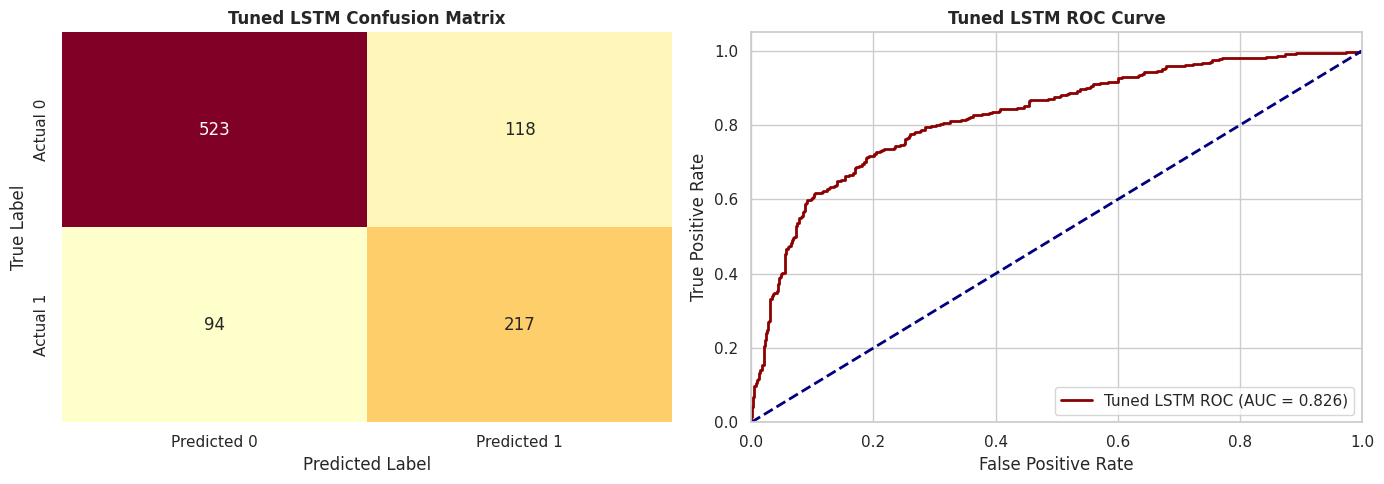


Tuned LSTM charts saved directly to shared Drive folder:
   /content/drive/MyDrive/Hackathon_05 06/team_lstm_tuned_evaluation.png


In [43]:

# 4. INITIALIZE TUNER AND RUN SEARCH

print("\n Step 3: Initializing RandomSearch optimization engine...")
tuner = kt.RandomSearch(
    build_model,
    objective=kt.Objective("val_auc", direction="max"), # Maximize validation ROC-AUC
    max_trials=5, # Tests 5 distinct parameter combinations
    executions_per_trial=1,
    directory='lstm_tuning_dir',
    project_name='vaccine_lstm'
)

# Run early stopping to truncate bad trails early
stop_early = EarlyStopping(monitor='val_loss', patience=3)

print("⚡ Running Hyperparameter Search trials...")
tuner.search(
    X_train_lstm, y_train,
    epochs=15,
    validation_data=(X_val_lstm, y_val),
    class_weight=class_weights,
    callbacks=[stop_early],
    verbose=1
)

# Fetch and report the winner combination
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\n================  OPTIMAL PARAMETERS FOUND ================")
print(f" Best LSTM Units: {best_hps.get('lstm_units')}")
print(f"Best Dropout Layer 1: {best_hps.get('dropout_1'):.1f}")
print(f"Best Dropout Layer 2: {best_hps.get('dropout_2'):.1f}")
print(f"Best Learning Rate: {best_hps.get('learning_rate')}\n")

# ==========================================
# 5. TRAIN FINAL BEST MODEL
# ==========================================
print(" Training the finalized model using optimal configurations...")
best_model = tuner.hypermodel.build(best_hps)
final_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

best_model.fit(
    X_train_lstm, y_train,
    epochs=35,
    batch_size=32,
    validation_data=(X_val_lstm, y_val),
    class_weight=class_weights,
    callbacks=[final_stop],
    verbose=0
)

# ==========================================
# 6. EVALUATION AND PLOT GENERATION
# ==========================================
y_pred_proba = best_model.predict(X_val_lstm).flatten()
y_pred = (y_pred_proba >= 0.5).astype(int)

print("\n================  TUNED LSTM EVALUATION REPORT ================ ")
tuned_auc = roc_auc_score(y_val, y_pred_proba)
print(f" Tuned LSTM Validation ROC-AUC: {tuned_auc:.4f}\n")
print(classification_report(y_val, y_pred, target_names=['Not Vaccinated (0)', 'Vaccinated (1)']))

# Draw Dashboards
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0], cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
axes[0].set_title('Tuned LSTM Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
axes[1].plot(fpr, tpr, color='darkred', lw=2, label=f'Tuned LSTM ROC (AUC = {tuned_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Tuned LSTM ROC Curve', fontweight='bold')
axes[1].legend(loc="lower right")

plt.tight_layout()

# Save final graphic to your shared Drive
output_plot_path = file_path.replace('super_dataset_C_train.csv', 'team_lstm_tuned_evaluation.png')
plt.savefig(output_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTuned LSTM charts saved directly to shared Drive folder:\n   {output_plot_path}")